In [1]:
<< "MaTeX`"
<< "~/Documentos/Wolfram Mathematica/Wolfram_scripts/Optics_Mie.wls"
<< "~/Documentos/Wolfram Mathematica/Wolfram_scripts/Optical_functions/Au_JohnsnChristy.wls"

In [4]:
radius = {5.78, 7.3};
nNP = JohnsonChristyAuRefSize[#1, #2] &;
wlen = Range[388, 947, 5.];

(*
data = Flatten@{#,ReIm[nNP[#,radius[[1]] ]]} &/@ wlen;
Export["nAu5nm.csv",data]

data = Flatten@{#,ReIm[nNP[#, radius[[2]] ]]} &/@ wlen;
Export["nAu7nm.csv",data]
*)

Legended[-Graphics-, Placed[Automati, After, Identity]]
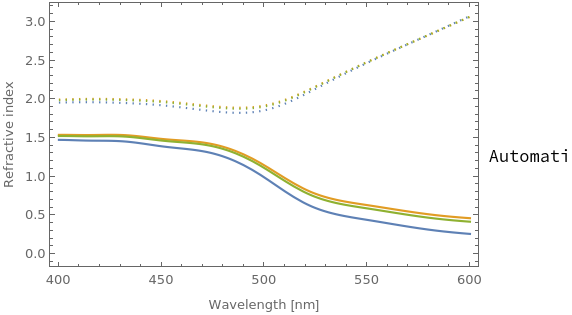

In [8]:
ReImPlot[{nNP[x,80],nNP[x,5.78],nNP[x,7.30]},{x,400,600}, 
    Frame -> True,
    FrameLabel -> {"Wavelength [nm]", "Refractive index"},
    PlotLegends -> Automati]

In [17]:
scaQ[lda_]:= Map[MieScatteringQ[{1., nNP[#, radius[[1]] ]}, #, radius[[1]]]&, lda]
extQ[lda_]:= Map[MieExtinctionQ[{1., nNP[#, radius[[1]] ]}, #, radius[[1]]]&, lda] 

In [19]:
wlen = Range[480, 600, 5.];
scaMie = scaQ[wlen];
absMie = extQ[wlen] - scaMie;

{-Graphics-, -Graphics-}
{-Graphics-, -Graphics-}
{-Graphics-, -Graphics-}
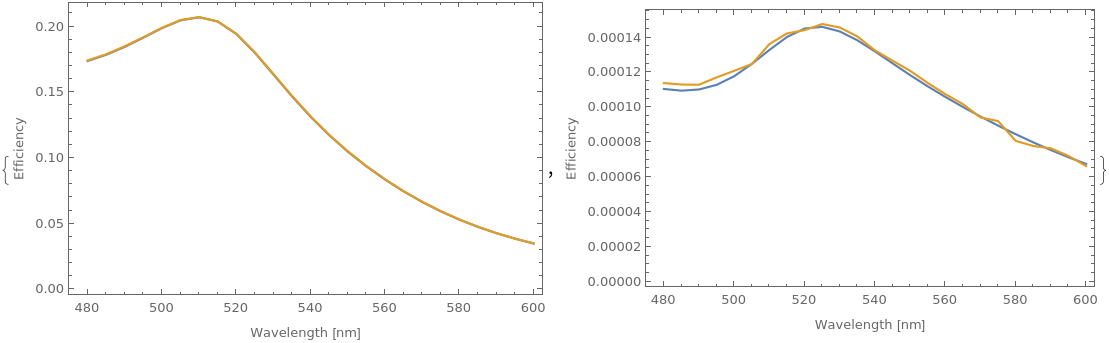
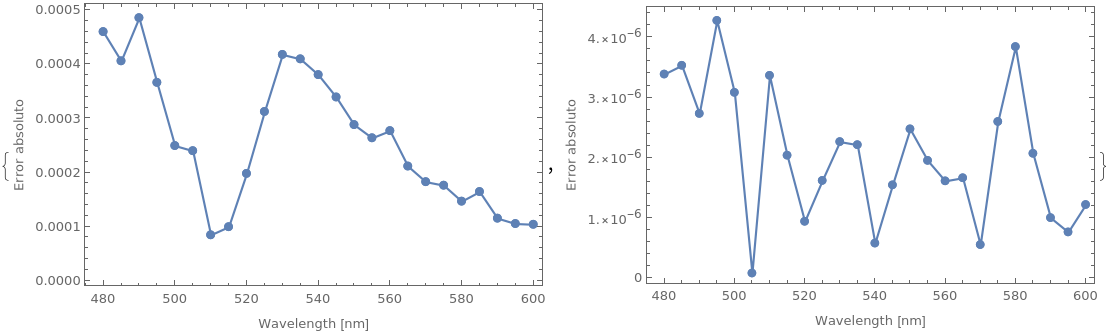
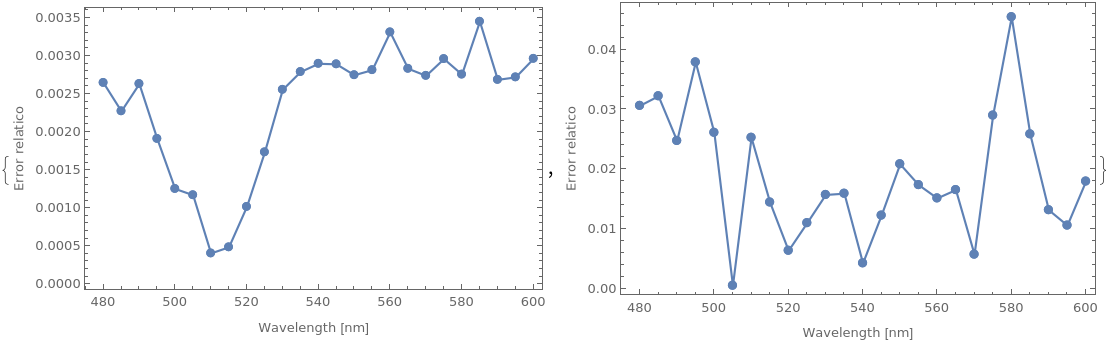

In [30]:
data = Import[#,"Data"] &@@ FileNames["*.csv","Pruebas"];
data = Transpose[Drop[data,5,{1}]];

wlen = data[[1]];

scaMie = scaQ[wlen];
absMie = extQ[wlen] - scaMie;

ListLinePlot[#,
    DataRange -> wlen[[{1,-1}]],
    Frame -> True,
    FrameLabel -> {"Wavelength [nm]", "Efficiency"},
    ImageSize -> 400] & /@ {{absMie,data[[2]]}, {scaMie,data[[3]]}}

ListLinePlot[Abs[#],
    Mesh -> Full,
    DataRange -> wlen[[{1,-1}]],
    Frame -> True,
    FrameLabel -> {"Wavelength [nm]", "Error absoluto"},
    ImageSize -> 400] & /@ {absMie-data[[2]], scaMie-data[[3]]}

ListLinePlot[Abs[#],
    Mesh -> Full,
    DataRange -> wlen[[{1,-1}]],
    Frame -> True,
    FrameLabel -> {"Wavelength [nm]", "Error relatico"},
    ImageSize -> 400] & /@ {(absMie-data[[2]])/absMie, (scaMie-data[[3]])/scaMie}

In [39]:
DeleteDuplicates[Join[Range[480,600,10.],Range[500,540,2.5]]]

{480., 490., 500., 510., 520., 530., 540., 550., 560., 570., 580., 590., 600., 502.5, 
 
>   505., 507.5, 512.5, 515., 517.5, 522.5, 525., 527.5, 532.5, 535., 537.5}